In [1]:
import slangpy as spy
from pyglm import glm
import matplotlib.pyplot as plt
import numpy as np
import quaternion
import PIL

from bvhgs import device
from bvhgs.camera import Camera
from bvhgs.gaussian import GaussianCloud
from bvhgs.renderer import Renderer
from bvhgs.prefix_sum import prefix_sum
from bvhgs.radix_sort import radix_sort
import pathlib

[INFO] (rhi) layer: CreateDevice: Debug layer is enabled.
[WARN] No supported shader model found, pretending to support sm_6_0.


In [2]:
np.random.seed(0)

# Create Gaussian Buffer

In [3]:
gaussians = GaussianCloud()
gaussians.load_from_ply(pathlib.Path("../resources/scenes/truck/truck.ply"))
len(gaussians)

148916

# Load Module and Shader

In [4]:
module = device.load_module("renderer.slang")
module

SlangModule(
  name = renderer.slang,
  path = /Users/fangjun/Documents/stanford/bvhgs/src/bvhgs/slang/renderer.slang,
  entry_points = [
    SlangEntryPoint(name="project", stage=compute),
    SlangEntryPoint(name="cull", stage=compute),
    SlangEntryPoint(name="computeTile", stage=compute),
    SlangEntryPoint(name="buildGaussianTable", stage=compute),
    SlangEntryPoint(name="duplicateGaussian", stage=compute),
    SlangEntryPoint(name="rasterize", stage=compute),
  ]
)

In [5]:
program = device.link_program([module], [])
program

ShaderProgram(
  modules = [
    SlangModule(
      name = renderer.slang,
      path = /Users/fangjun/Documents/stanford/bvhgs/src/bvhgs/slang/renderer.slang,
      entry_points = [
        SlangEntryPoint(name="project", stage=compute),
        SlangEntryPoint(name="cull", stage=compute),
        SlangEntryPoint(name="computeTile", stage=compute),
        SlangEntryPoint(name="buildGaussianTable", stage=compute),
        SlangEntryPoint(name="duplicateGaussian", stage=compute),
        SlangEntryPoint(name="rasterize", stage=compute),
      ]
    ),
  ],
  entry_points = []
)

# Projection

## Build Slang Buffer and Camera Parameter

In [6]:
# Create a buffer for the Gaussian points.
gaussian_buf = device.create_buffer(
    element_count=len(gaussians),
    struct_type=program.reflection.g_gaussian_3d,
    usage=spy.BufferUsage.shader_resource,
)
# Store all the gaussian points in the buffer.
gaussian_cursor = spy.BufferCursor(
    program.reflection.g_gaussian_3d.type_layout.element_type_layout,
    gaussian_buf,
)

for i in range(len(gaussians)):
    gaussian_cursor[i].write(gaussians[i])
gaussian_cursor.apply()

In [7]:
# Create a buffer for the Gaussian2D points.
gaussian2d_buf = device.create_buffer(
    element_count=len(gaussians),
    struct_type=program.reflection.g_gaussian_2d,
    usage=spy.BufferUsage.shader_resource | spy.BufferUsage.unordered_access,
)
gaussian2d_buf

Buffer(
  device = 0x11730d0c8,
  size = 11913280,
  struct_size = 80,
  format = undefined,
  usage = (shader_resource | unordered_access),
  memory_type = device_local,
  memory_usage = 11.36 MB,
  label = 
)

In [8]:
cam_rot_mat = np.array([
    [
        0.786188006401062,
        -0.01644204743206501,
        -0.6177687048912048
    ],
    [
        -0.028784452006220818,
        0.9975867867469788,
        -0.06318280845880508
    ],
    [
        0.6173167824745178,
        0.0674557015299797,
        0.7838174700737
    ]

])
cam_pos = np.array([
      0.6305696964263916,
      0.13185331225395203,
      -0.4680609107017517
])
cam_trans = - cam_rot_mat.T @ cam_pos
cam_rot = quaternion.from_rotation_matrix(cam_rot_mat.T)
cam_rot, cam_trans

(quaternion(0.944403539151829, -0.0345822787193282, 0.326948537728537, 0.00326724857488682),
 array([-0.20300915, -0.08959389,  0.76475141]))

In [9]:
camera = Camera(
    rotation=glm.quat(quaternion.as_float_array(cam_rot)),
    translation=glm.vec3(cam_trans),
    sensor_size=glm.uvec2(979, 546),
    focal_length=580,
    near_plane=0.001,
    far_plane=100
)
camera.to_slang()

{'_rotation': [-0.03458227962255478,
  0.32694852352142334,
  0.0032672486267983913,
  0.9444035291671753],
 '_translation': vec3( -0.203009, -0.0895939, 0.764751 ),
 '_sensorSize': uvec2( 979, 546 ),
 '_focalLength': 580,
 '_nearPlane': 0.001,
 '_farPlane': 100}

In [10]:
cursor = spy.BufferCursor(
    program.reflection.g_gaussian_3d.type_layout.element_type_layout,
    gaussian_buf,
)
cursor[0]

{'position': {-0.07346803, -0.05500152, 0.20971616}, 'rotation': {-0.7626261, 0.5860386, 0.27172825, -0.03352422}, 'scale': {-5.921904, -5.4502006, -6.0199356}, 'color': {-0.43895376, -0.41628563, -0.050231364}, 'opacity': 0.11774029582738876, 'sh': [{-0.004677673, -0.004905257, 0.018343339}, {3.391951e-05, 4.9046234e-06, -8.982926e-05}, {4.8851132e-05, 0.00013369083, 0}, {0, 0, 0}, {0, 0, 0}, {-0.006341042, -0.0041992925, 0.0066080526}, {-1.3040767e-05, -1.7898415e-06, 3.850754e-05}, {-1.9313393e-05, -6.299296e-05, 0}, {0, 0, 0}, {0, 0, 0}, {-0.013500715, -0.011401326, -0.0017421666}, {-1.4709774e-05, -2.0271448e-06, 4.3040225e-05}, {-2.173598e-05, -6.9796515e-05, 0}, {0, 0, 0}, {0, 0, 0}]} [Gaussian3D]

## Dispatch Projection Kernel

In [11]:
ker_proj = device.create_compute_kernel(
    device.link_program([module], [module.entry_point("project")])
)
ker_proj

ComputeKernel(0x1676bb9f0)

In [12]:
# Create flag buffer for culling.
inside_flag_buf = device.create_buffer(
    element_count=len(gaussians),
    struct_type=program.reflection.g_inside_flag,
    usage=spy.BufferUsage.shader_resource | spy.BufferUsage.unordered_access,
)
inside_flag_buf

Buffer(
  device = 0x11730d0c8,
  size = 595664,
  struct_size = 4,
  format = undefined,
  usage = (shader_resource | unordered_access),
  memory_type = device_local,
  memory_usage = 581.70 kB,
  label = 
)

In [13]:
ker_proj.dispatch(
    thread_count=[len(gaussians), 1, 1],
    vars={
        "g_camera": camera.to_slang(),
        "g_gaussian_3d": gaussian_buf,
        "g_gaussian_2d": gaussian2d_buf,
        "g_inside_flag": inside_flag_buf
    }
)

In [14]:
cursor = spy.BufferCursor(
    program.reflection.g_gaussian_2d.type_layout.element_type_layout,
    gaussian2d_buf,
)
cursor.element_count
cursor[0]

{'position': {0.42141646, 0.6402341, 0.009939801}, 'covariance': {{3.6446831e-06, -1.8368825e-06}, {-1.8368822e-06, 1.040882e-05}}, 'color': {0.38482323, 0.39198205, 0.49217752}, 'opacity': 0.5294011235237122, 'cachedInvCov': {{301157.5, 53146.36}, {53146.355, 105451.305}}} [Gaussian2D]

## Cull Gaussians

In [15]:
ker_cull = device.create_compute_kernel(
    device.link_program([module], [module.entry_point("cull")])
)

In [16]:
# Cull the Gaussian points.
inside_offset_buf = prefix_sum(inside_flag_buf)
inside_offset_cursor = spy.BufferCursor(
    program.reflection.g_inside_offset.type_layout.element_type_layout,
    inside_offset_buf,
)
# Read the last element of the cull prefix buffer to get the number of culled points.
num_viewing = int(inside_offset_cursor[len(inside_offset_cursor) - 1].read())  # type: ignore
num_viewing

98932

In [17]:
# Culled gaussians
culled_gaussian_buf = device.create_buffer(
    element_count=num_viewing,
    struct_type=program.reflection.g_gaussian_2d_culled,
    usage=spy.BufferUsage.shader_resource | spy.BufferUsage.unordered_access,
)
culled_gaussian_buf

Buffer(
  device = 0x11730d0c8,
  size = 7914560,
  struct_size = 80,
  format = undefined,
  usage = (shader_resource | unordered_access),
  memory_type = device_local,
  memory_usage = 7.55 MB,
  label = 
)

In [18]:
ker_cull.dispatch(
    thread_count=[len(gaussians), 1, 1],
    vars={
        "g_gaussian_2d": gaussian2d_buf,
        "g_inside_flag": inside_flag_buf,
        "g_inside_offset": inside_offset_buf,
        "g_gaussian_2d_culled": culled_gaussian_buf
    }
)

In [19]:
cursor = spy.BufferCursor(
    program.reflection.g_gaussian_2d_culled.type_layout.element_type_layout,
    culled_gaussian_buf,
)
cursor[0]

{'position': {0.42141646, 0.6402341, 0.009939801}, 'covariance': {{3.6446831e-06, -1.8368825e-06}, {-1.8368822e-06, 1.040882e-05}}, 'color': {0.38482323, 0.39198205, 0.49217752}, 'opacity': 0.5294011235237122, 'cachedInvCov': {{301157.5, 53146.36}, {53146.355, 105451.305}}} [Gaussian2D]

# Tiling

In [20]:
ker_tile = device.create_compute_kernel(
    device.link_program([module], [module.entry_point("computeTile")])
)
ker_build_gs = device.create_compute_kernel(
    device.link_program([module], [module.entry_point("buildGaussianTable")])
)

In [21]:
num_tile_buf = device.create_buffer(
    element_count=num_viewing,
    struct_type=program.reflection.g_num_tile,
    usage=spy.BufferUsage.shader_resource | spy.BufferUsage.unordered_access,
)
num_tile_buf

Buffer(
  device = 0x11730d0c8,
  size = 395728,
  struct_size = 4,
  format = undefined,
  usage = (shader_resource | unordered_access),
  memory_type = device_local,
  memory_usage = 386.45 kB,
  label = 
)

In [22]:
ker_tile.dispatch(
    thread_count=[num_viewing, 1, 1],
    vars={
        "g_gaussian_2d_culled": culled_gaussian_buf,
        "g_num_tile": num_tile_buf
    }
)

In [23]:
num_tile_arr = num_tile_buf.to_numpy().view(np.uint32)
num_table_entries = np.sum(num_tile_arr).item()
num_table_entries

190582

In [24]:
gaussian_table_buf = device.create_buffer(
    element_count=num_table_entries,
    struct_type=program.reflection.g_gaussian_table,
    usage=spy.BufferUsage.shader_resource | spy.BufferUsage.unordered_access,
)
gaussian_table_buf

Buffer(
  device = 0x11730d0c8,
  size = 3049312,
  struct_size = 16,
  format = undefined,
  usage = (shader_resource | unordered_access),
  memory_type = device_local,
  memory_usage = 2.91 MB,
  label = 
)

In [25]:
num_tile_prefix_buf = prefix_sum(num_tile_buf)

In [26]:
ker_build_gs.dispatch(
    thread_count=[num_viewing, 1, 1],
    vars={
        "g_gaussian_2d_culled": culled_gaussian_buf,
        "g_num_tile_prefix": num_tile_prefix_buf,
        "g_gaussian_table": gaussian_table_buf,
    }
)

# Sort Tile

In [27]:
gaussian_table_buf_sorted, hist_buf = radix_sort(
    src_buf=gaussian_table_buf,
    bits_per_pass=8,
    total_bits=40
)

[WARN] (rhi) slang: metal 32023.619: /Users/fangjun/Documents/stanford/bvhgs/src/bvhgs/slang/radix-sort.slang(36): warning :  unused variable '_S1' [-Wunused-variable]
    uint _S1 = atomic_fetch_add_explicit((&kernelContext_0)->entryPointParams_state_hist_0+uint(((((&kernelContext_0)->entryPointParams_state_src_0+tid_1)->key_0) >> ((&kernelContext_0)->entryPointParams_0->state_0.shift_0)) & ulong((&kernelContext_0)->entryPointParams_0->state_0.mask_0)), 1U, memory_order_relaxed);
         ^
1 warning generated.



In [28]:
gaussian_table_arr = gaussian_table_buf_sorted.to_numpy().view(np.uint64).reshape(-1, 2)
idx = np.argsort(gaussian_table_arr[:, 0])
gaussian_table_arr = gaussian_table_arr[idx]
gaussian_table_buf_sorted.copy_from_numpy(gaussian_table_arr)

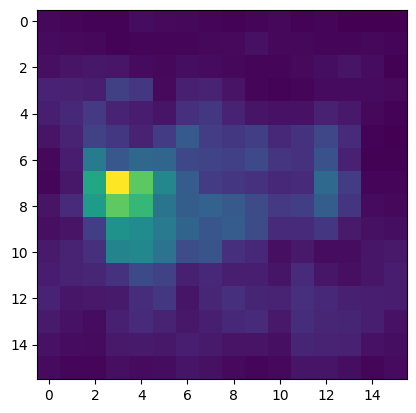

In [29]:
plt.imshow(hist_buf.to_numpy().view(np.uint32).reshape(16, 16))

# Rasterize

In [30]:
ker_duplicate = device.create_compute_kernel(
    device.link_program([module], [module.entry_point("duplicateGaussian")])
)
ker_rasterize = device.create_compute_kernel(
    device.link_program([module], [module.entry_point("rasterize")])
)

In [31]:
gaussian_2d_sorted_buf = device.create_buffer(
    element_count=num_table_entries,
    struct_type=program.reflection.g_gaussian_2d_sorted,
    usage=spy.BufferUsage.shader_resource | spy.BufferUsage.unordered_access,
)
gaussian_2d_sorted_buf

Buffer(
  device = 0x11730d0c8,
  size = 15246560,
  struct_size = 80,
  format = undefined,
  usage = (shader_resource | unordered_access),
  memory_type = device_local,
  memory_usage = 14.54 MB,
  label = 
)

In [32]:
ker_duplicate.dispatch(
    thread_count=[num_table_entries, 1, 1],
    vars={
        "g_gaussian_2d_culled": culled_gaussian_buf,
        "g_gaussian_table": gaussian_table_buf_sorted,
        "g_gaussian_2d_sorted": gaussian_2d_sorted_buf
    }
)

In [33]:
render_target = device.create_texture(
    type=spy.TextureType.texture_2d,
    format=spy.Format.rgba32_float,
    width=camera.sensor_size.x,
    height=camera.sensor_size.y,
    usage=spy.TextureUsage.shader_resource
    | spy.TextureUsage.unordered_access,
)

In [34]:
hist_arr = hist_buf.to_numpy().view(np.uint32)
hist_offs = np.zeros_like(hist_arr)
hist_offs[1:] = np.cumsum(hist_arr)[:-1]

In [35]:
tile_offst_buf = device.create_buffer(
    element_count=len(hist_offs),
    struct_type=program.reflection.g_tile_offs,
    usage=spy.BufferUsage.shader_resource | spy.BufferUsage.unordered_access,
)
tile_offst_buf.copy_from_numpy(hist_offs)

In [36]:
ker_rasterize.dispatch(
    thread_count=[camera.sensor_size.x, camera.sensor_size.y, 1],
    vars={
        "g_camera": camera.to_slang(),
        "g_tile_hist": hist_buf,
        "g_tile_offs": tile_offst_buf,
        "g_gaussian_2d_sorted": gaussian_2d_sorted_buf,
        "g_render_target": render_target
    }
)

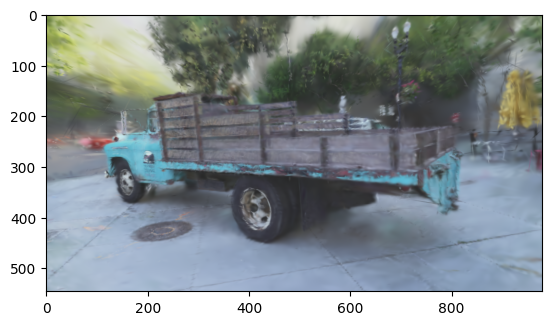

In [37]:
raw_image = render_target.to_numpy()
plt.imshow(raw_image)

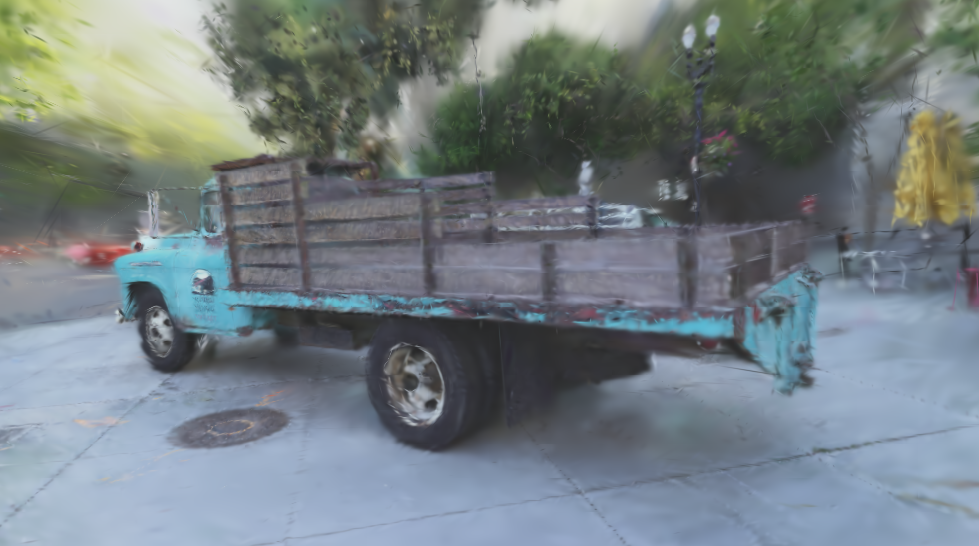

In [39]:
# Convert the raw image to a PIL image and save it.
image = PIL.Image.fromarray((raw_image * 255).astype(np.uint8))
image.save(".temp/gaussian_render.png")
image